In [23]:
import pandas as pd

independent_features = pd.read_csv('smartphone_battery_features.csv')
dependent_feature = pd.read_csv('smartphone_battery_targets.csv')
df = independent_features.merge(dependent_feature, on='Device_ID', how='inner')
df.head()

,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent,recommended_action
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04,32.8,Change Phone
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23,50.3,Replace Battery
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21,66.1,Replace Battery
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13,46.8,Change Phone
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95,67.2,Replace Battery


In [24]:
df.shape

(5000, 17)

In [25]:
df.drop(columns=['Device_ID'], inplace=True)

In [26]:
df.shape

(5000, 16)

In [27]:
df.isnull().sum()

device_age_months                   0
battery_capacity_mah                0
avg_screen_on_hours_per_day         0
avg_charging_cycles_per_week        0
avg_battery_temp_celsius            0
fast_charging_usage_percent         0
overnight_charging_freq_per_week    0
gaming_hours_per_week               0
video_streaming_hours_per_week      0
background_app_usage_level          0
signal_strength_avg                 0
charging_habit_score                0
usage_intensity_score               0
thermal_stress_index                0
current_battery_health_percent      0
recommended_action                  0
dtype: int64

In [28]:
print(df.duplicated().sum())

0


In [29]:
df.head()

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent,recommended_action
0,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04,32.8,Change Phone
1,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23,50.3,Replace Battery
2,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21,66.1,Replace Battery
3,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13,46.8,Change Phone
4,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95,67.2,Replace Battery


In [30]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :14]
Y = df.iloc[:, 14]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [31]:
X_train.head()

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
1840,13,5000,5.7,8.4,34.6,62.0,1,4.2,7.3,Medium,Good,8,10.0,3.74
2115,42,3000,10.7,14.2,36.5,97.1,1,7.4,12.8,High,Good,6,10.0,4.41
4437,22,4000,6.4,8.8,33.6,61.1,5,4.9,8.6,Medium,Moderate,5,10.0,3.53
1146,32,3000,3.5,3.6,32.4,22.8,7,5.6,8.0,High,Good,6,10.0,3.31
2486,15,4000,7.1,11.5,38.2,68.6,5,12.6,11.0,High,Good,6,10.0,5.18


In [32]:
X_test.head()

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
1501,15,4000,5.8,8.8,34.0,41.4,3,4.1,11.7,Medium,Good,6,10.0,3.57
2586,45,4000,2.5,3.0,36.0,12.2,3,5.3,10.8,Medium,Good,8,10.0,4.13
2653,36,4500,5.3,8.2,33.8,17.0,0,6.2,5.1,High,Moderate,9,10.0,3.69
1055,0,5000,5.6,9.2,33.4,32.0,6,2.4,6.4,High,Good,6,10.0,3.30
705,17,4000,5.4,7.6,34.8,56.4,3,1.7,10.3,High,Good,6,10.0,3.58


In [33]:
import joblib
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in X_train.select_dtypes(include='object'):
    le = LabelEncoder()
    X_train[column] = le.fit_transform(X_train[column])
    X_test[column] = le.transform(X_test[column])
    label_encoders[column] = le
    
joblib.dump(label_encoders, 'Label-Encoders.bin')
print("Label Encoders saved as 'Label-Encoders.bin'")

Label Encoders saved as 'Label-Encoders.bin'


In [34]:
X_train.head()

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
1840,13,5000,5.7,8.4,34.6,62.0,1,4.2,7.3,2,0,8,10.0,3.74
2115,42,3000,10.7,14.2,36.5,97.1,1,7.4,12.8,0,0,6,10.0,4.41
4437,22,4000,6.4,8.8,33.6,61.1,5,4.9,8.6,2,1,5,10.0,3.53
1146,32,3000,3.5,3.6,32.4,22.8,7,5.6,8.0,0,0,6,10.0,3.31
2486,15,4000,7.1,11.5,38.2,68.6,5,12.6,11.0,0,0,6,10.0,5.18


In [35]:
X_test.head()

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
1501,15,4000,5.8,8.8,34.0,41.4,3,4.1,11.7,2,0,6,10.0,3.57
2586,45,4000,2.5,3.0,36.0,12.2,3,5.3,10.8,2,0,8,10.0,4.13
2653,36,4500,5.3,8.2,33.8,17.0,0,6.2,5.1,0,1,9,10.0,3.69
1055,0,5000,5.6,9.2,33.4,32.0,6,2.4,6.4,0,0,6,10.0,3.30
705,17,4000,5.4,7.6,34.8,56.4,3,1.7,10.3,0,0,6,10.0,3.58


In [36]:
print(f'Training data input shape : {X_train.shape}')
print(f'Testing data input shape  : {X_test.shape}')

Training data input shape : (3500, 14)
Testing data input shape  : (1500, 14)


In [37]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor, XGBRFRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

rfc = RandomForestRegressor(random_state=42)
abc = AdaBoostRegressor(random_state=42)
gbc = GradientBoostingRegressor(random_state=42)
xgbc = XGBRegressor(random_state=42)
xgbc_rf = XGBRFRegressor(random_state=42)
lgbmc = LGBMRegressor(random_state=42)
cbc = CatBoostRegressor(verbose=0, random_state=42)

classifier_model_dict = {
    'Random Forest Regressor': rfc,
    'AdaBoost Regressor': abc,
    'Gradient Boosting Regressor': gbc,
    'XGBoost Regressor': xgbc,
    'XGBoost RF-Booster': xgbc_rf,
    'LightGBM Regressor': lgbmc,
    'CatBoost Regressor': cbc
}

for model_name, model in classifier_model_dict.items():
    print(f'\n-------------------- {model_name} --------------------')
    model.fit(X_train, Y_train)
    Y_pred_train = model.predict(X_train)
    Y_pred_test = model.predict(X_test)
    
    print(f"Train R²-Score : {r2_score(Y_train, Y_pred_train):.4f}")
    print(f"Test R²-Score  : {r2_score(Y_test, Y_pred_test):.4f}")


-------------------- Random Forest Regressor --------------------
Train R²-Score : 0.9941
Test R²-Score  : 0.9579

-------------------- AdaBoost Regressor --------------------
Train R²-Score : 0.9354
Test R²-Score  : 0.9300

-------------------- Gradient Boosting Regressor --------------------
Train R²-Score : 0.9728
Test R²-Score  : 0.9635

-------------------- XGBoost Regressor --------------------
Train R²-Score : 0.9967
Test R²-Score  : 0.9572

-------------------- XGBoost RF-Booster --------------------
Train R²-Score : 0.9564
Test R²-Score  : 0.9424

-------------------- LightGBM Regressor --------------------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1316
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 13
[LightGBM] [Info] Start training from score 62.597257
Train R²-Score : 0.9855
Test R²-S

In [38]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)
    
joblib.dump(std_scaler, 'Standard-Scaler.bin')
print("Label Encoder saved as 'Standard-Scaler.bin'")

Label Encoder saved as 'Standard-Scaler.bin'


In [39]:
X_train.shape

(3500, 14)

In [40]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout

def DNN_Model(input_shape):
    input = Input(shape=input_shape)
    
    x = Dense(256, activation='relu')(input)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    output = Dense(1)(x)
    
    model = Model(inputs=input, outputs=output)
    model.compile(optimizer='Adam', loss='mae', metrics=['r2_score'])
    return model

input_shape = (X_train.shape[1],)
model = DNN_Model(input_shape)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,849 (183.00 KB)

 Trainable params: 45,953 (179.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('DNN_Model.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)

print('✅ Starting Deep Neural Network Model Training....\n')
history = model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_data=(X_test, Y_test), callbacks=[early_stop, checkpoint], verbose=1)
print("\n✅ Model Training Completed. Best model saved as 'DNN_Model.keras'")

✅ Starting Deep Neural Network Model Training....

Epoch 1/50
 99/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 61.7998 - r2_score: -11.9370
Epoch 1: val_loss improved from None to 61.28510, saving model to DNN_Model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 61.9220 - r2_score: -12.1810 - val_loss: 61.2851 - val_r2_score: -11.9961
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 60.2019 - r2_score: -11.8882
Epoch 2: val_loss improved from 61.28510 to 57.40091, saving model to DNN_Model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 59.1912 - r2_score: -11.1097 - val_loss: 57.4009 - val_r2_score: -10.5028
Epoch 3/50
 92/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54.6834 - r2_score: -9.4440
Epoch 3: val_loss improved from 57.40091 to 48.87188, saving model to DNN_Model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 52.8844 - r2_score: -8.9057 - val_loss: 48.8719 - val_r2_score: -7.5159
Epoch 4/50
104/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 46

In [42]:
from sklearn.metrics import r2_score

Y_pred_train = model.predict(X_train)
Y_pred_test = model.predict(X_test)

print(f"Train R²-Score : {r2_score(Y_train, Y_pred_train):.4f}")
print(f"Test R²-Score  : {r2_score(Y_test, Y_pred_test):.4f}")

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Train R²-Score : 0.9684
Test R²-Score  : 0.9612


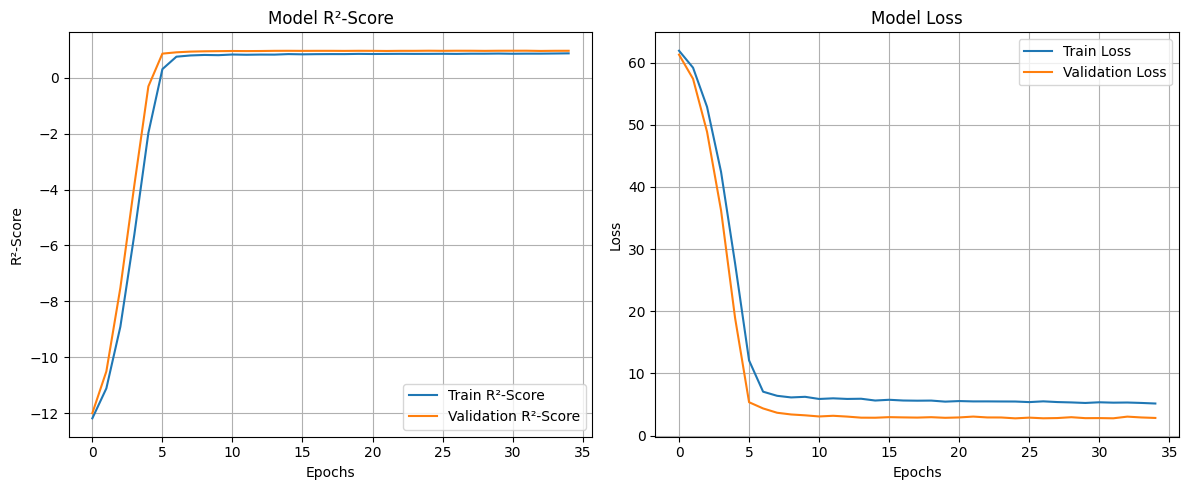

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Plot R²-Score
plt.subplot(1, 2, 1)
plt.plot(history.history['r2_score'], label='Train R²-Score')
plt.plot(history.history['val_r2_score'], label='Validation R²-Score')
plt.title('Model R²-Score')
plt.xlabel('Epochs')
plt.ylabel('R²-Score')
plt.legend()
plt.grid(True)

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
from tensorflow.keras.models import load_model

X_full = df.iloc[:, :14].copy()

encoders = joblib.load('Label-Encoders.bin')
for column in X_full.select_dtypes(include='object'):
    X_full[column] = encoders[column].transform(X_full[column])

scaler = joblib.load('Standard-Scaler.bin')
X_full_scaled = scaler.transform(X_full)

model = load_model('DNN_Model.keras')

print("Generating predictions for the full dataset...")
predictions = model.predict(X_full_scaled, verbose=1)

df['Predicted_Output'] = predictions

output_file = 'smartphone_battery_health_with_predictions.csv'
df.to_csv(output_file, index=False)

print(f"\n✅ Predictions saved successfully to: {output_file}")
print(df[['current_battery_health_percent', 'Predicted_Output']].head())

Generating predictions for the full dataset...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

✅ Predictions saved successfully to: smartphone_battery_health_with_predictions.csv
   current_battery_health_percent  Predicted_Output
0                            32.8         32.496521
1                            50.3         52.552086
2                            66.1         73.547493
3                            46.8         44.565094
4                            67.2         68.321983
